# Simulación Dinámica de N-Cuerpos
Este *notebook* implementa una simulación gravitatoria de $N$ cuerpos resolviendo numéricamente las ecuaciones de movimiento de Newton.

El objetivo es calcular las trayectorias planetarias partiendo de unas condiciones iniciales de masa, posición y velocidad, y generar los archivos de datos correspondientes a las órbitas (`planets_data.dat`) y a la evolución de la energía (`energia_momento.txt`).

## 1. El Algoritmo de Verlet (Velocity Verlet)
Para integrar las ecuaciones de movimiento, utilizamos el algoritmo de **Velocity Verlet**. A diferencia de métodos más simples como Euler, Verlet calcula la posición y la velocidad de forma sincronizada, ofreciendo una precisión de segundo orden local.

Las ecuaciones de actualización iterativa son:

1. **Posición:** Se actualiza usando la velocidad actual y la aceleración actual.
$$\vec{r}(t+h) = \vec{r}(t) + \vec{v}(t)h + \frac{1}{2}\vec{a}(t)h^2$$

2. **Aceleración:** Se calculan las nuevas fuerzas gravitatorias basándose en las *nuevas* posiciones $\vec{r}(t+h)$.

3. **Velocidad:** Se completa el paso temporal promediando la aceleración antigua y la nueva.
$$\vec{v}(t+h) = \vec{v}(t) + \frac{h}{2} \left[ \vec{a}(t) + \vec{a}(t+h) \right]$$

En el código en C++, esto se divide calculando primero una "velocidad intermedia" $\vec{w}$ para optimizar los cálculos.

## 2. Conservación de Energía y Momento Angular
Una de las mayores ventajas de usar Velocity Verlet es que es un **integrador simpléctico**. Esto significa que preserva la geometría del espacio de fases del sistema (Teorema de Liouville).

* **Conservación de la Energía ($E$):** Aunque el algoritmo no conserva la energía exacta del sistema iteración a iteración con precisión infinita, sí conserva exactamente un Hamiltoniano. Esto hace que la energía total oscile ligeramente alrededor de un valor constante, evitando la deriva de energía hacia el infinito que destruiría las órbitas a largo plazo.
* **Conservación del Momento Angular ($L$):** Dado que el campo gravitatorio es central e isótropo (simetría rotacional continua), el Teorema de Noether garantiza la conservación de $L$. En nuestro código, monitorear que $L$ se mantiene estable es la mejor prueba de que la simulación es físicamente correcta.

## 3. Preparación del entorno
El código en C++ requiere un archivo llamado `condiciones_i.txt` .

In [12]:
# ========================================================
# GENERADOR DE CONDICIONES INICIALES (condiciones_i.txt)
# ========================================================
# Formato: pos_x (10^6 km) | vel_y (km/s) | masa (10^24 kg)

condiciones = [
    "0.0\t0.0\t1989000.0\n",      # 0. Sol
    "69.82\t38.86\t0.3301\n",      # 1. Mercurio
    "108.94\t34.79\t4.8676\n",     # 2. Venus
    "152.10\t29.29\t5.9726\n",     # 3. Tierra
    "249.23\t21.97\t0.64174\n",    # 4. Marte
    "816.62\t12.44\t1898.3\n",     # 5. Júpiter
    "1514.50\t9.09\t568.36\n",     # 6. Saturno
    "3003.62\t6.49\t86.816\n",     # 7. Urano
    "4545.67\t5.37\t102.42\n",     # 8. Neptuno
    "7375.93\t3.71\t0.0131\n"      # 9. Plutón
]

print("Generando archivo de condiciones_i.txt...")

with open("condiciones_i.txt", "w") as f:
    f.writelines(condiciones)

print("¡Archivo creado con éxito! Contiene 10 cuerpos celestes listo para compilar.")

Generando archivo de condiciones_i.txt...
¡Archivo creado con éxito! Contiene 10 cuerpos celestes listo para compilar.


In [13]:
%%writefile simulacion.cpp
#include <cmath>
#include <iostream>
#include <iomanip>
#include <fstream>

using namespace std;

// $$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
// DEFINICIÓN DE CONSTANTES (PARÁMETROS)
// $$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#define ARCHIVO_ENTRADA "condiciones_i.txt"
#define ARCHIVO_SALIDA "planets_data.dat"
#define ARCHIVO_ENERGIA "energia_momento.txt"

#define MAX_CUERPOS 100
#define ITERACIONES 1000000
#define PASO_TIEMPO 0.001

#define MASA_SOLAR 1.989e30
#define UNIDAD_ASTRONOMICA 1.496e11
#define FACTOR_TIEMPO 5022004.955

// ==========================================
// ARRAYS PARA LAS PROPIEDADES FÍSICAS
// ==========================================
double masas[MAX_CUERPOS], pos_x[MAX_CUERPOS], pos_y[MAX_CUERPOS];
double vel_x[MAX_CUERPOS], vel_y[MAX_CUERPOS];
double acel_x[MAX_CUERPOS], acel_y[MAX_CUERPOS];
double w_x[MAX_CUERPOS], w_y[MAX_CUERPOS];

// Variables para periodos
double periodos[MAX_CUERPOS] = {0};
double y_ant[MAX_CUERPOS] = {0};
bool tiene_vuelta[MAX_CUERPOS] = {0};

int main() {
    int n = 0;
    float t = 0;
    long double E = 0, L = 0;

    // 1. LECTURA DE DATOS
    ifstream entrada(ARCHIVO_ENTRADA);
    if (!entrada) {
        cout << "Error al abrir " << ARCHIVO_ENTRADA << endl;
        return 1;
    }

    while(entrada >> pos_x[n] >> vel_y[n] >> masas[n]) {
        n++;
    }
    entrada.close();

    // 2. REESCALAMIENTO
    for (int i = 0; i < n; i++) {
        pos_x[i] *= 1e6 * 1000 / UNIDAD_ASTRONOMICA;
        pos_y[i] = 0;
        masas[i] *= 1e24 / MASA_SOLAR;
        vel_x[i] = 0;
        vel_y[i] *= 1000 / UNIDAD_ASTRONOMICA * FACTOR_TIEMPO;
    }

    // 3. ARCHIVOS Y ACELERACIÓN INICIAL
    ofstream f_salida(ARCHIVO_SALIDA);
    ofstream f_energia(ARCHIVO_ENERGIA);

    // Escribir t=0
    for (int i = 0; i < n; i++) f_salida << pos_x[i] << "," << pos_y[i] << "\n";
    f_salida << "\n";

    // Cálculo inicial de aceleraciones según la ley de gravitación
    for (int i = 0; i < n; i++) {
        acel_x[i] = acel_y[i] = 0;
        for (int j = 0; j < n; j++) {
            if (i != j) {
                float r = sqrt(pow(pos_x[i]-pos_x[j], 2) + pow(pos_y[i]-pos_y[j], 2));
                acel_x[i] += -masas[j] * (pos_x[i] - pos_x[j]) / pow(r, 3);
            }
        }
    }

    // 4. ALGORITMO DE VERLET
    for (int k = 0; k < ITERACIONES; k++) {
        t += PASO_TIEMPO;
        E = 0; L = 0;

        // A) Posiciones
        for (int i = 0; i < n; i++) {
            y_ant[i] = pos_y[i];

            // Velocidad intermedia W
            w_x[i] = vel_x[i] + (PASO_TIEMPO / 2.0) * acel_x[i];
            w_y[i] = vel_y[i] + (PASO_TIEMPO / 2.0) * acel_y[i];

            // Nueva posición r(t+h)
            pos_x[i] += PASO_TIEMPO * vel_x[i] + (pow(PASO_TIEMPO, 2) / 2.0) * acel_x[i];
            pos_y[i] += PASO_TIEMPO * vel_y[i] + (pow(PASO_TIEMPO, 2) / 2.0) * acel_y[i];

            // NUEVO: ¡Solo guardamos 1 de cada 100 pasos!
            if (k % 10 == 0) {
                f_salida << pos_x[i] << "," << pos_y[i] << "\n";
            }
        }

        // NUEVO: El salto de línea también lo hacemos solo 1 de cada 100 veces
        if (k % 10 == 0) {
            f_salida << "\n";
        }

        // B) Aceleraciones nuevas a partir de r(t+h)
        for (int i = 0; i < n; i++) {
            acel_x[i] = acel_y[i] = 0;
            for (int j = 0; j < n; j++) {
                if (i != j) {
                    float r = sqrt(pow(pos_x[i]-pos_x[j], 2) + pow(pos_y[i]-pos_y[j], 2));
                    acel_x[i] += -masas[j] * (pos_x[i] - pos_x[j]) / pow(r, 3);
                    acel_y[i] += -masas[j] * (pos_y[i] - pos_y[j]) / pow(r, 3);
                }
            }
        }

        // C) Velocidades finales v(t+h)
        for (int i = 0; i < n; i++) {
            vel_x[i] = w_x[i] + (PASO_TIEMPO / 2.0) * acel_x[i];
            vel_y[i] = w_y[i] + (PASO_TIEMPO / 2.0) * acel_y[i];

            // Periodos
            if (pos_x[i] > 0 && pos_y[i] * y_ant[i] < 0 && k > 100 && i != 0 && !tiene_vuelta[i]) {
                tiene_vuelta[i] = true;
                periodos[i] = k * PASO_TIEMPO * FACTOR_TIEMPO / 86400.0;
                cout << "Planeta " << i << ": Periodo de " << periodos[i] << " dias." << endl;
            }
        }

        // D) Energía y Momento
        for (int i = 0; i < n; i++) {
            L += masas[i] * (pos_x[i] * vel_y[i] - pos_y[i] * vel_x[i]);
            E += 0.5 * masas[i] * (pow(vel_x[i], 2) + pow(vel_y[i], 2));
            for (int j = 0; j < n; j++) {
                if (i != j) {
                    float r = sqrt(pow(pos_x[i]-pos_x[j], 2) + pow(pos_y[i]-pos_y[j], 2));
                    E += -masas[i] * masas[j] / (2.0 * r);
                }
            }
        }
        f_energia << fixed << setprecision(7) << t << "\t" << E << "\t" << L << "\n";
    }

    f_salida.close();
    f_energia.close();
    cout << "Simulacion terminada. Tiempo total: " << t * FACTOR_TIEMPO / 86400.0 << " dias terrestres." << endl;

    return 0;
}

Overwriting simulacion.cpp


In [14]:
# Compilamos el código C++
!g++ -O3 simulacion.cpp -o n_cuerpos

# Ejecutamos y REDIRIGIMOS la salida a un archivo de texto
!./n_cuerpos > salida_consola.txt

# Mostramos por pantalla el archivo para ver que todo fue bien
!cat salida_consola.txt

Planeta 1: Periodo de 87.9432 dias.
Planeta 2: Periodo de 224.653 dias.
Planeta 3: Periodo de 364.967 dias.
Planeta 4: Periodo de 686.283 dias.
Planeta 5: Periodo de 4326.42 dias.
Planeta 6: Periodo de 10730.5 dias.
Planeta 7: Periodo de 30296.2 dias.
Simulacion terminada. Tiempo total: 57610.2 dias terrestres.


## 5. Análisis Gráfico de las Variables de Conservación (Python)
Una vez finalizada la simulación en C++, los datos de la energía y el momento angular total quedan registrados en el archivo `energia_momento.txt`.

Utilizaremos **Pandas** para la manipulación eficiente de la serie temporal y **Matplotlib** para representar visualmente el comportamiento de ambas magnitudes. El script generará un lienzo con dos subgráficas y guardará automáticamente las imágenes tanto en formato de alta resolución (`.png`) como en formato vectorial (`.pdf`), ideal para su posterior inclusión en memorias académicas o informes en LaTeX.

Leyendo datos de energia_momento.txt...
Guardando imágenes...
Abriendo ventana de gráficas...


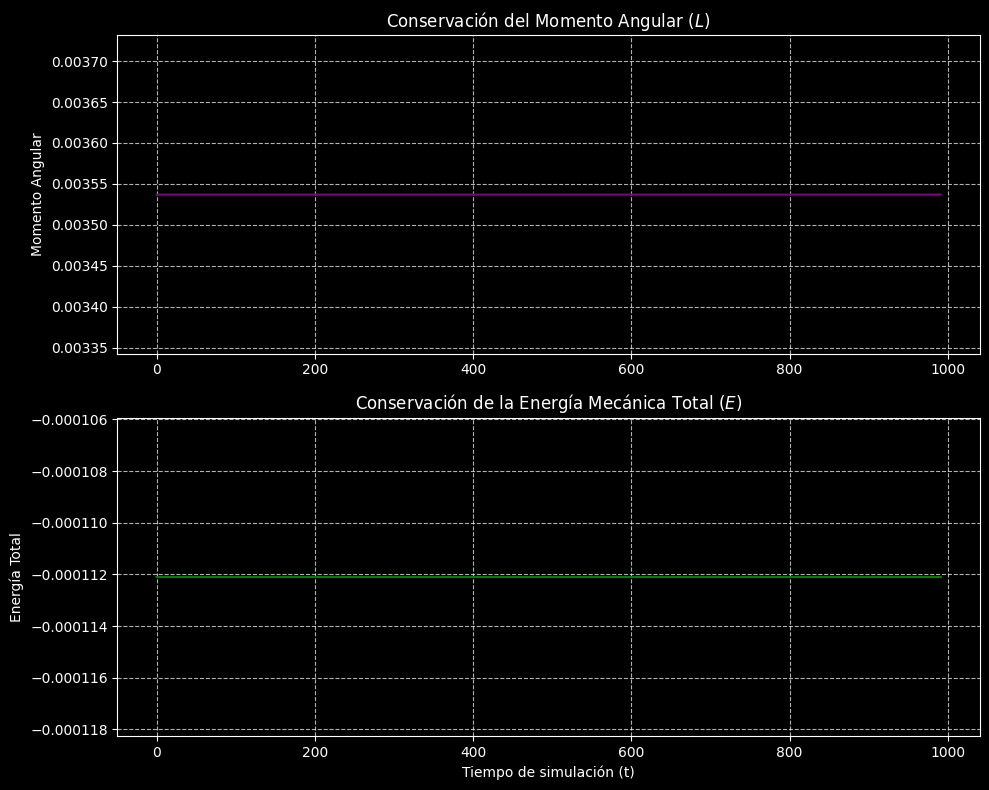

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ========================================================
# ANÁLISIS DE CONSERVACIÓN: ENERGÍA Y MOMENTO ANGULAR
# ========================================================

print("Leyendo datos de energia_momento.txt...")

# 1. Leer los datos generados
energia = pd.read_csv("energia_momento.txt", sep="\t", names=["t", "E", "L"])

# 2. Crear la figura con dos subgráficas (una encima de la otra)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# --- Gráfica Superior: Momento Angular (L) ---
ax1.plot(energia['t'], energia['L'], color='purple')
ax1.set_title("Conservación del Momento Angular ($L$)")
ax1.set_ylabel("Momento Angular")
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Gráfica Inferior: Energía Total (E) ---
ax2.plot(energia['t'], energia['E'], color='green')
ax2.set_title("Conservación de la Energía Mecánica Total ($E$)")
ax2.set_xlabel("Tiempo de simulación (t)")
ax2.set_ylabel("Energía Total")
ax2.grid(True, linestyle='--', alpha=0.7)

# 3. Ajustar espacios, guardar y mostrar
plt.tight_layout()

print("Guardando imágenes...")
plt.savefig("conservacion_E_L.png", dpi=300)
plt.savefig("conservacion_E_L.pdf")

print("Abriendo ventana de gráficas...")
plt.show()

In [16]:
import pandas as pd
import re
from IPython.display import display, Markdown

# ========================================================
# VALIDACIÓN AUTOMÁTICA DE PERIODOS ORBITALES
# ========================================================

# Valores astronómicos reales aproximados (Días terrestres)
# Los índices (1 al 9) coinciden con el orden en tu archivo condiciones_i.txt (0 es el Sol)
periodos_reales = {
    1: ("Mercurio", 87.97),
    2: ("Venus", 224.70),
    3: ("Tierra", 365.25),
    4: ("Marte", 686.98),
    5: ("Júpiter", 4332.59),
    6: ("Saturno", 10759.22),
    7: ("Urano", 30688.50),
    8: ("Neptuno", 60182.00),
    9: ("Plutón", 90560.00)
}

resultados = []

# 1. Leemos el archivo donde el C++ escupió los resultados
try:
    with open("salida_consola.txt", "r") as f:
        texto_consola = f.read()
except FileNotFoundError:
    print("Error: No se encuentra salida_consola.txt. Ejecuta primero el C++.")
    texto_consola = ""

# 2. Buscamos las líneas de los periodos usando expresiones regulares
# Busca el patrón exacto que imprime tu C++: "Planeta X: Periodo de Y dias."
patron = r"Planeta (\d+): Periodo de ([\d\.]+) dias"
coincidencias = re.findall(patron, texto_consola)

# 3. Calculamos los errores relativos
for planeta_id, periodo_sim in coincidencias:
    planeta_id = int(planeta_id)
    periodo_sim = float(periodo_sim)

    if planeta_id in periodos_reales:
        nombre, periodo_real = periodos_reales[planeta_id]

        # Fórmula del error relativo porcentual
        error_relativo = abs(periodo_sim - periodo_real) / periodo_real * 100

        resultados.append({
            "Cuerpo Celeste": nombre,
            "T_real (días)": periodo_real,
            "T_simulado (días)": round(periodo_sim, 2),
            "Error Relativo (%)": round(error_relativo, 3)
        })

# 4. Renderizamos la tabla dinámicamente
if resultados:
    df_periodos = pd.DataFrame(resultados)

    # Imprimimos el título en formato Markdown
    display(Markdown("### 7. Validación del Modelo: Comparativa de Periodos Orbitales"))
    display(Markdown("Al comparar los resultados impresos por el integrador de Verlet con los valores astronómicos reales, obtenemos el siguiente margen de error para los cuerpos que han completado al menos una órbita:"))

    # Mostramos el DataFrame (Colab lo renderiza como una tabla interactiva)
    display(df_periodos)
else:
    print("Aún no se han detectado periodos completos.")
    print("Asegúrate de que la simulación tiene suficientes ITERACIONES para completar una órbita.")

### 7. Validación del Modelo: Comparativa de Periodos Orbitales

Al comparar los resultados impresos por el integrador de Verlet con los valores astronómicos reales, obtenemos el siguiente margen de error para los cuerpos que han completado al menos una órbita:

,Cuerpo Celeste,T_real (días),T_simulado (días),Error Relativo (%)
0,Mercurio,87.97,87.94,0.030
1,Venus,224.70,224.65,0.021
2,Tierra,365.25,364.97,0.077
3,Marte,686.98,686.28,0.101
4,Júpiter,4332.59,4326.42,0.142
5,Saturno,10759.22,10730.50,0.267
6,Urano,30688.50,30296.20,1.278


#Gráfica del sistema de referencia terrestre

Procesando trayectorias desde planets_data.dat...
Gráfica generada y guardada como orbitas_relativas.png


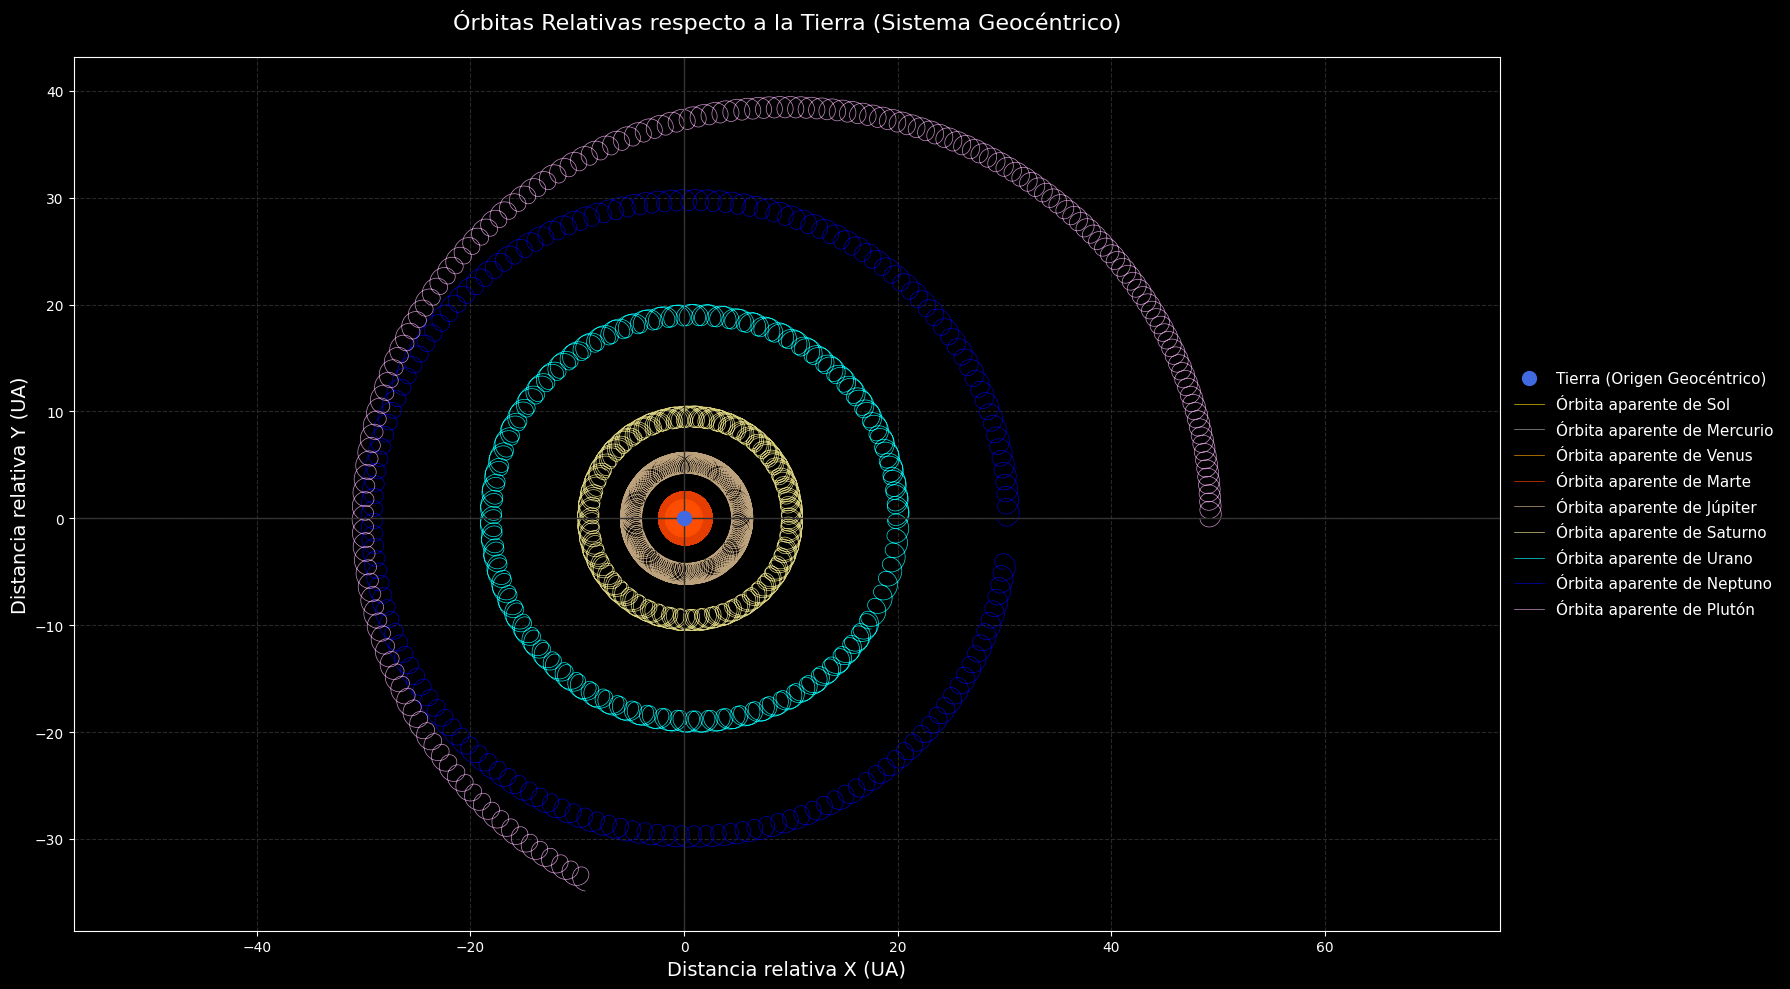

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# LECTURA DE DATOS Y CAMBIO DE SISTEMA DE REFERENCIA
# ========================================================
print("Procesando trayectorias desde planets_data.dat...")

# 1. Leer el archivo con estructura de bloques separados por líneas en blanco
datos_simulacion = []
bloque_temporal = []

with open("planets_data.dat", "r") as f:
    for linea in f:
        linea = linea.strip()
        if not linea:  # Línea en blanco indica cambio de instante temporal
            if bloque_temporal:
                datos_simulacion.append(bloque_temporal)
                bloque_temporal = []
        else:
            x, y = map(float, linea.split(","))
            bloque_temporal.append([x, y])

# Añadir el último bloque si el archivo no termina en línea en blanco
if bloque_temporal:
    datos_simulacion.append(bloque_temporal)

# Convertir a un array 3D de Numpy: Shape = (Num_Pasos, Num_Planetas, 2_Coordenadas)
trayectorias = np.array(datos_simulacion)

num_pasos = trayectorias.shape[0]
num_planetas = trayectorias.shape[1]

# 2. Extraer las coordenadas de la Tierra
# OJO: Con tus 10 datos iniciales, la Tierra es el índice 3.
# (0: Sol, 1: Mercurio, 2: Venus, 3: Tierra, 4: Marte...)
indice_tierra = 3
tierra_x = trayectorias[:, indice_tierra, 0]
tierra_y = trayectorias[:, indice_tierra, 1]

# 3. Configurar el lienzo
# CAMBIO: Aumentamos el tamaño general, dándole mucho más ancho (18) respecto al alto (10)
plt.figure(figsize=(18, 10))
plt.style.use('dark_background') # Fondo oscuro para estilo "espacial"

# Pintar la Tierra estática en el centro (0,0)
plt.plot(0, 0, 'o', color='#4169E1', markersize=10, label="Tierra (Origen Geocéntrico)", zorder=10)

# 4. Calcular y dibujar las órbitas relativas de TODOS los cuerpos
nombres_base = ["Sol", "Mercurio", "Venus", "Tierra", "Marte", "Júpiter", "Saturno", "Urano", "Neptuno", "Plutón"]
colores = ["#FFD700", "#A9A9A9", "#FFA500", "#4169E1", "#FF4500", "#D2B48C", "#F0E68C", "#00FFFF", "#0000CD", "#DDA0DD"]

for i in range(num_planetas):
    if i == indice_tierra:
        continue # Saltamos la Tierra porque su órbita relativa respecto a sí misma es 0

    # Resta vectorial: Posición del cuerpo 'i' menos Posición de la Tierra
    x_relativo = trayectorias[:, i, 0] - tierra_x
    y_relativo = trayectorias[:, i, 1] - tierra_y

    nombre = nombres_base[i] if i < len(nombres_base) else f"Cuerpo {i}"
    color_trazo = colores[i] if i < len(colores) else "white"

    # Dibujar la órbita relativa
    # CAMBIO: Reducimos linewidth a 0.5 para que las líneas sean mucho más finas
    plt.plot(x_relativo, y_relativo, color=color_trazo, linewidth=0.5, alpha=0.9, label=f"Órbita aparente de {nombre}")

# 5. Detalles estéticos de la gráfica
plt.title("Órbitas Relativas respecto a la Tierra (Sistema Geocéntrico)", fontsize=16, pad=20, color='white')
plt.xlabel("Distancia relativa X (UA)", fontsize=14)
plt.ylabel("Distancia relativa Y (UA)", fontsize=14)

# Ejes cruzados más discretos
plt.axhline(0, color='#333333', linewidth=1)
plt.axvline(0, color='#333333', linewidth=1)

# Cuadrícula sutil adaptada al fondo oscuro
plt.grid(True, linestyle='--', color='#333333', alpha=0.8)

# Leyenda fuera del gráfico para no tapar los dibujos geocéntricos
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, frameon=False)
plt.axis('equal') # Mantener la proporción real (círculos no se ven ovalados)

# Guardar y mostrar ajustando los márgenes para que quepa la leyenda
plt.tight_layout()
plt.savefig("orbitas_relativas.png", dpi=300, bbox_inches='tight')
print("Gráfica generada y guardada como orbitas_relativas.png")
plt.show()